In [1]:
!pip install torch torchvision scikit-learn matplotlib seaborn

In [5]:
import os, random, copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_score, recall_score, f1_score)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)
print('Libraries loaded!')


Using device: cpu
Libraries loaded!


In [7]:
BASE       = os.getcwd()
TRAIN_PATH = os.path.join(BASE, 'archive_extracted', 'Training')
TEST_PATH  = os.path.join(BASE, 'archive_extracted', 'Testing')

print('Training folder:', TRAIN_PATH)
print('Testing  folder:', TEST_PATH)
print('Train exists:', os.path.exists(TRAIN_PATH))
print('Test  exists:', os.path.exists(TEST_PATH))

IMG_SIZE    = 128
BATCH_SIZE  = 32
NUM_CLASSES = 4
EPOCHS      = 15
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']


Training folder: C:\Users\ARCHANA\computervision_cw\archive_extracted\Training
Testing  folder: C:\Users\ARCHANA\computervision_cw\archive_extracted\Testing
Train exists: True
Test  exists: True


In [9]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
test_dataset  = datasets.ImageFolder(TEST_PATH,  transform=test_transform)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print('Classes:', train_dataset.classes)
print(f'Train: {len(train_dataset)} images  |  Test: {len(test_dataset)} images')


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train: 5600 images  |  Test: 1600 images


In [11]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds       = outputs.argmax(1)
            correct    += (preds == labels).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader.dataset), correct / len(loader.dataset), all_preds, all_labels


def train_model(model, train_loader, test_loader, epochs, lr, name):
    model     = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history  = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0.0
    best_wts = copy.deepcopy(model.state_dict())

    print(f'\n--- Training: {name} ---')
    for epoch in range(1, epochs + 1):
        t_loss, t_acc        = train_one_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc, _, _  = evaluate(model, test_loader, criterion)
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)

        if v_acc > best_acc:
            best_acc = v_acc
            best_wts = copy.deepcopy(model.state_dict())

        print(f'  Epoch {epoch:02d}/{epochs}  '
              f'Train Loss: {t_loss:.4f}  Train Acc: {t_acc:.4f}  '
              f'Val Loss: {v_loss:.4f}  Val Acc: {v_acc:.4f}')

    model.load_state_dict(best_wts)
    print(f'✅ Best Val Accuracy: {best_acc:.4f}')
    return model, history


print('Helper functions ready!')


Helper functions ready!


In [13]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 3 → 32 feature maps, image 128 → 64
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2: 32 → 64, 64 → 32
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3: 64 → 128, 32 → 16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Linear(256, 4),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


print(BaselineCNN())


BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=4, bias=True)
  )
)


In [15]:
model1, history = train_model(
    model        = BaselineCNN(),
    train_loader = train_loader,
    test_loader  = test_loader,
    epochs       = EPOCHS,
    lr           = 0.001,
    name         = 'Baseline CNN'
)

torch.save(model1.state_dict(), 'model1_baseline.pth')
print('Model 1 saved!')



--- Training: Baseline CNN ---
  Epoch 01/15  Train Loss: 0.7605  Train Acc: 0.6963  Val Loss: 0.9210  Val Acc: 0.7381
  Epoch 02/15  Train Loss: 0.4466  Train Acc: 0.8246  Val Loss: 0.8140  Val Acc: 0.7831
  Epoch 03/15  Train Loss: 0.3374  Train Acc: 0.8720  Val Loss: 0.8065  Val Acc: 0.8356
  Epoch 04/15  Train Loss: 0.2627  Train Acc: 0.9029  Val Loss: 0.7145  Val Acc: 0.8519
  Epoch 05/15  Train Loss: 0.1986  Train Acc: 0.9252  Val Loss: 0.7867  Val Acc: 0.8806
  Epoch 06/15  Train Loss: 0.1303  Train Acc: 0.9532  Val Loss: 0.8690  Val Acc: 0.8888
  Epoch 07/15  Train Loss: 0.1002  Train Acc: 0.9657  Val Loss: 0.9145  Val Acc: 0.9081
  Epoch 08/15  Train Loss: 0.0844  Train Acc: 0.9680  Val Loss: 0.9040  Val Acc: 0.9044
  Epoch 09/15  Train Loss: 0.0686  Train Acc: 0.9766  Val Loss: 0.9975  Val Acc: 0.9219
  Epoch 10/15  Train Loss: 0.0614  Train Acc: 0.9773  Val Loss: 1.0969  Val Acc: 0.9150
  Epoch 11/15  Train Loss: 0.0388  Train Acc: 0.9886  Val Loss: 1.2977  Val Acc: 0.9263


In [17]:
criterion = nn.CrossEntropyLoss()
_, acc, preds, labels = evaluate(model1, test_loader, criterion)

print(f'Test Accuracy : {acc:.4f}')
prec = precision_score(labels, preds, average='weighted', zero_division=0)
rec  = recall_score(   labels, preds, average='weighted', zero_division=0)
f1   = f1_score(       labels, preds, average='weighted', zero_division=0)
print(f'Precision     : {prec:.4f}')
print(f'Recall        : {rec:.4f}')
print(f'F1 Score      : {f1:.4f}')


Test Accuracy : 0.9319
Precision     : 0.9361
Recall        : 0.9319
F1 Score      : 0.9299


In [31]:
!pip install seaborn
import sys
!{sys.executable} -m pip install seaborn
import seaborn as sns

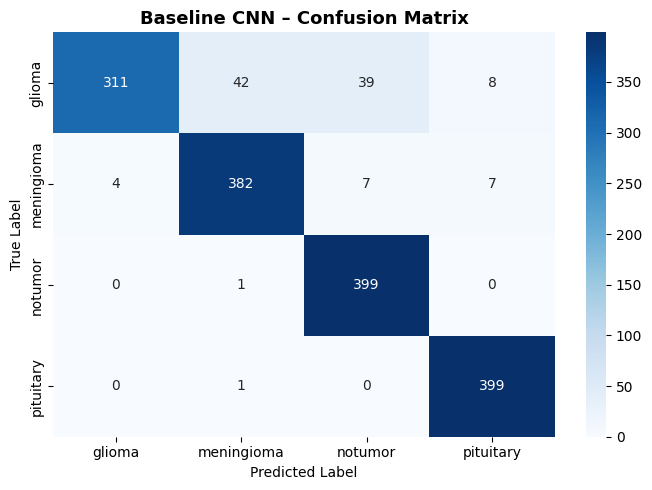

Saved: model1_confusion_matrix.png


In [32]:
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Baseline CNN – Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('model1_confusion_matrix.png')
plt.show()
print('Saved: model1_confusion_matrix.png')


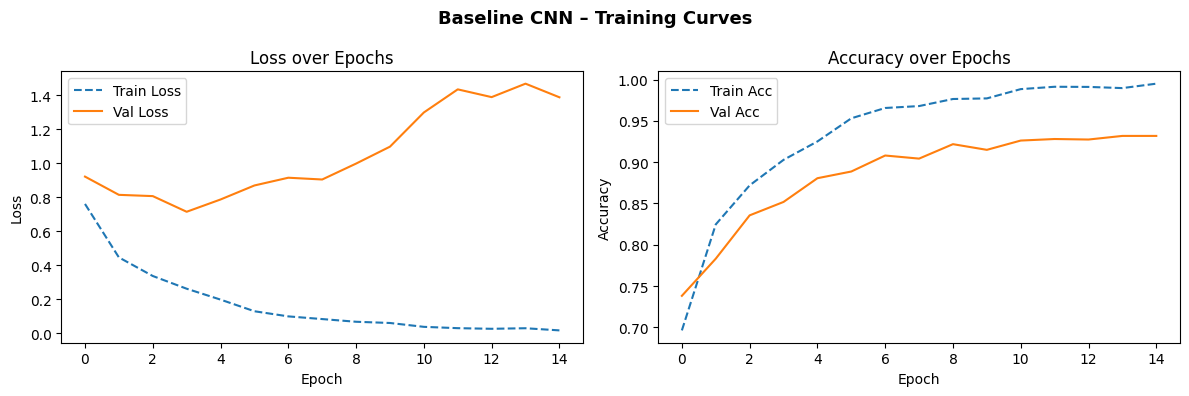

Saved: model1_training_curves.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], '--', label='Train Loss')
axes[0].plot(history['val_loss'],   '-',  label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history['train_acc'], '--', label='Train Acc')
axes[1].plot(history['val_acc'],   '-',  label='Val Acc')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Baseline CNN – Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model1_training_curves.png')
plt.show()
print('Saved: model1_training_curves.png')


In [21]:
print(classification_report(labels, preds, target_names=CLASS_NAMES))


              precision    recall  f1-score   support

      glioma       0.99      0.78      0.87       400
  meningioma       0.90      0.95      0.92       400
     notumor       0.90      1.00      0.94       400
   pituitary       0.96      1.00      0.98       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600

